# 3 — Read the results

Scoring a capture. **No cloud account required** if you are reading the
published `results/capture.json.gz`: it carries the oracle frozen into its
header, so the whole rubric runs locally.

This is the notebook to change if you disagree with how an answer is judged.
Capture and scoring are separate programs on purpose — `run_battery.py` records
what happened and never judges it, `src/scoring.py` judges and never re-runs an
agent. Editing the rubric costs a minute instead of a day.

`make report` is the non-interactive equivalent and writes
`results/report.md`. This notebook shows the same numbers with the charts.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path[:0] = [str(ROOT / "src"), str(ROOT / "examples")]

import battery
import plots
import report
import rescore
import traces

/home/user/git/vertex-ai-mlops/Applied ML/AI Agents/data-mcp-sandbox/.venv/lib/python3.11/site-packages/google/adk/features/_feature_decorator.py:71: UserWarning: [EXPERIMENTAL] feature FeatureName.PLUGGABLE_AUTH is enabled.
  check_feature_enabled()


## Which capture

The published one if it is present, otherwise your own sweep. The header is the
reproducibility block: it names the model, the temperature, the Toolbox version,
and — the field that decides whether the whole comparison means anything —
whether the per-tier service accounts were in force.

The published capture is **merged from two runs**, so there is no single commit
or start time to print; `provenance` names each run and the arms it produced
instead. Each run keeps its own oracle, because four of the twelve questions are
trailing windows anchored at build time and the right answer moves with the
calendar.

Three of those four turned out to be worse than drifty: their wording pins the
window's *length* and never its *anchor*, so `CURRENT_TIMESTAMP()` and the data's
latest row are both faithful readings and an agent picks between them run to run.
They are marked `scoreable: false` in the rubric, and every rate below is computed
over the **nine questions the oracle can arbitrate** — 45 cells per arm and tier,
not 60.


In [2]:
capture = traces.locate(ROOT / "results" / "capture.json.gz", battery.RESULTS_PATH)
cells = traces.load(capture)
meta = traces.read_header(capture)

print(f"{capture.relative_to(ROOT)}  -  {len(cells)} cells")
for field in ("agent_model", "temperature", "toolbox_version", "use_tier_sa", "runs"):
    print(f"  {field:<16} {meta.get(field)}")
print(f"  {'provenance':<16} {report.provenance(meta)}")

results/capture.json.gz  -  1440 cells
  agent_model      gemini-3.7-flash
  temperature      0.0
  toolbox_version  1.10.0
  use_tier_sa      True
  runs             5
  provenance       merged from 2 runs: `834421c3` (p1_managed, p1_toolbox, p2_managed, p2_toolbox, p3_managed, p3_toolbox, p1_matched, p3_matched, p4_bq_ca, p4_looker_ca, started 2026-09-05T02:07:23+00:00); `b987b497` (p4_bq_direct, p4_bq_direct_ctx, started 2026-09-07T14:26:18+00:00)


## Score it

`resolve_goldens` prefers goldens frozen into the capture. Falling back to live
BigQuery is right for whoever ran the sweep — the corpus anchors its timestamps
to build time, so a stored number rots as the sandbox ages — and impossible for
a reader, which is exactly why `make export` freezes them.

In [3]:
scores = rescore.score_all(cells, rescore.resolve_goldens(cells, meta))
print(f"scored {len(scores)} cells")

using goldens frozen into the capture (2 oracles across 12 arms)


scored 1440 cells


## Headline

Everything per **correct answer**, not per cell: an arm that is cheap and wrong
is not cheap.

Cost is reported in units consumed rather than dollars — tokens in, tokens out,
seconds, BigQuery jobs, MiB scanned. Those are five things you can check against
your own invoice. A dollar figure needs a rate card, and rates differ by region,
edition and committed-use discount, so it is the one number here guaranteed to
be wrong for most readers. It still exists, opt-in via `prices.json`.

Input and output are separate columns because they neither cost nor behave
alike, and the split is what makes the cost result legible: `p1_managed` at tier
0 spends over 1.6M input tokens per correct answer against about 5.5K output.
Almost none of the bill is the model thinking.

The BigQuery columns stay empty here because job attribution needs a live
`INFORMATION_SCHEMA` query — `make report` fills them in. The token and second
columns do not depend on that pass, which is the point: an offline read still
gets a usage table, not a row of dashes. An unmeasured value prints `--`, never
`0`.

In [4]:
print(report.headline(scores, costs={}))

| config | tier | accuracy (mean) | tokens in / correct | tokens out / correct | sec / correct | BQ jobs / correct | MiB / correct | coverage |
|---|---|---|---|---|---|---|---|---|
| p1_managed | 0 | 49% | 1163956 | 3790 | 190 | -- | -- | -- |
| p1_managed | 1 | 89% | 268637 | 1061 | 41 | -- | -- | -- |
| p1_toolbox | 0 | 44% | 175354 | 2528 | 160 | -- | -- | -- |
| p1_toolbox | 1 | 100% | 22267 | 669 | 34 | -- | -- | -- |
| p2_managed | 0 | 44% | 278217 | 3457 | 214 | -- | -- | -- |
| p2_managed | 1 | 98% | 40970 | 722 | 48 | -- | -- | -- |
| p2_toolbox | 0 | 42% | 395521 | 3848 | 215 | -- | -- | -- |
| p2_toolbox | 1 | 100% | 63826 | 750 | 33 | -- | -- | -- |
| p3_managed | 0 | 47% | 2151215 | 5063 | 239 | -- | -- | -- |
| p3_managed | 1 | 100% | 283550 | 965 | 46 | -- | -- | -- |
| p3_toolbox | 0 | 44% | 417432 | 2983 | 190 | -- | -- | -- |
| p3_toolbox | 1 | 100% | 53979 | 699 | 39 | -- | -- | -- |
| p1_matched | 0 | 47% | 252863 | 3066 | 162 | -- | -- | -- |
| p1_matched | 1 | 89

## Does governance help?

The one chart to look at if you look at one. Same data, same model, same
questions on both bars of every pair — the only difference is whether the
warehouse was governed.

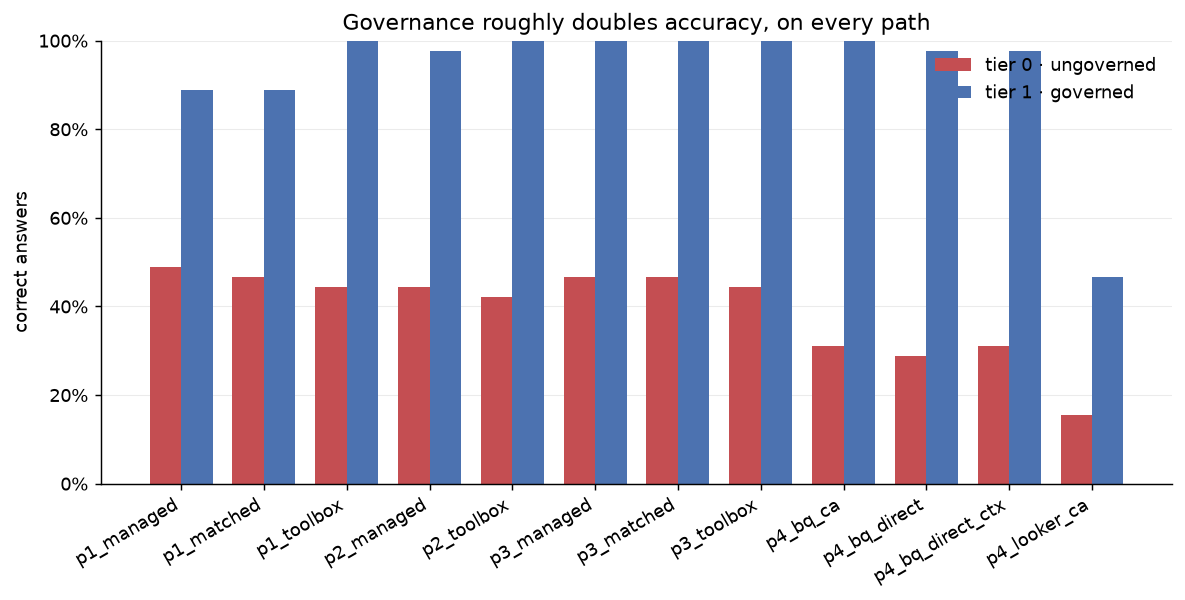

In [5]:
plots.accuracy_by_tier(scores)

## Is it enough?

No. Split the governed failures into *never acquired the rule* and *acquired it
and got the answer wrong anyway*. Acquisition is close to solved; application is
not, and that is the gap worth working on.

Path 4 is excluded rather than drawn as a zero bar: it discloses no query, so
there is no evidence to inspect. Ranking an arm bottom on a metric it was never
eligible for is a false finding, not a conservative one.

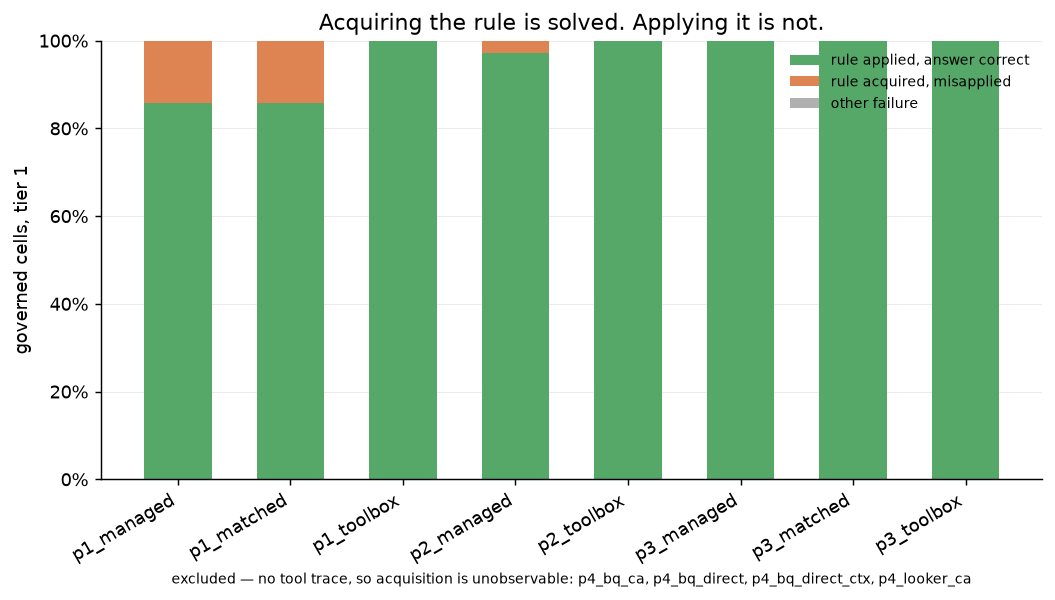

In [6]:
plots.acquisition_vs_application(scores)

## What does each arm cost?

Log x, because the arms span two orders of magnitude and that spread *is* the
finding — a linear axis collapses nine of them into one column.

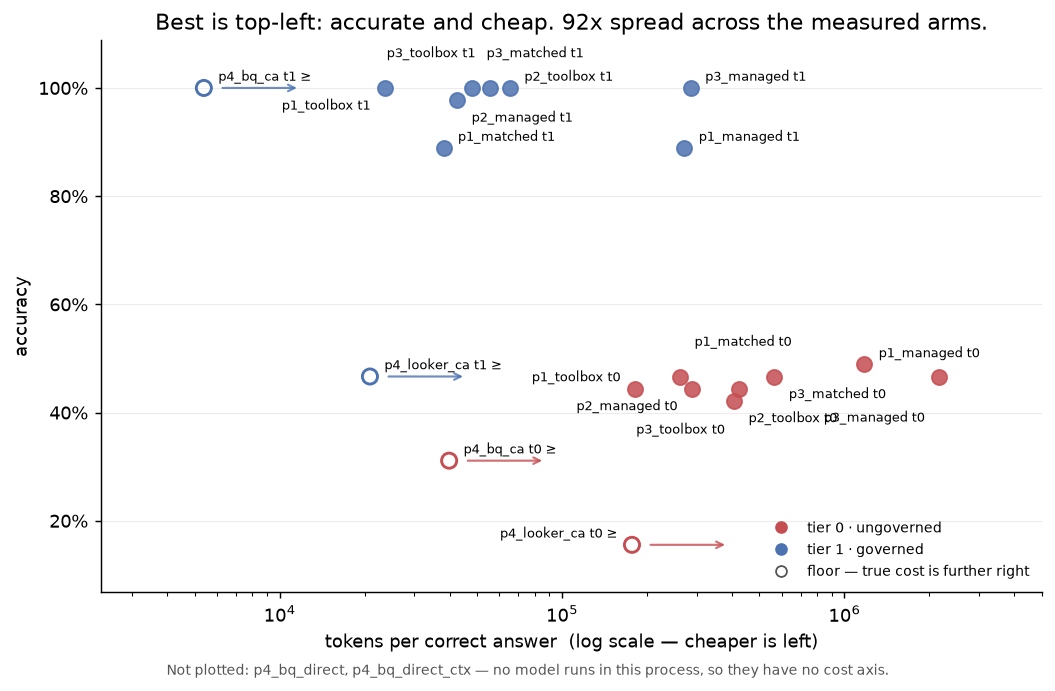

In [7]:
plots.cost_vs_accuracy(scores)

## Why does it cost that?

Tool declarations are re-sent to the model on **every turn**, so their
serialized size sets a floor under the whole conversation. Each capture measures
its own, at sweep time, into the header — because these are vendor schemas that
can change without notice, and this chart shows that detail dominating the cost
result. Tool *count* does not predict cost. Verbosity does. See
[`docs/paths.md`](../docs/paths.md).

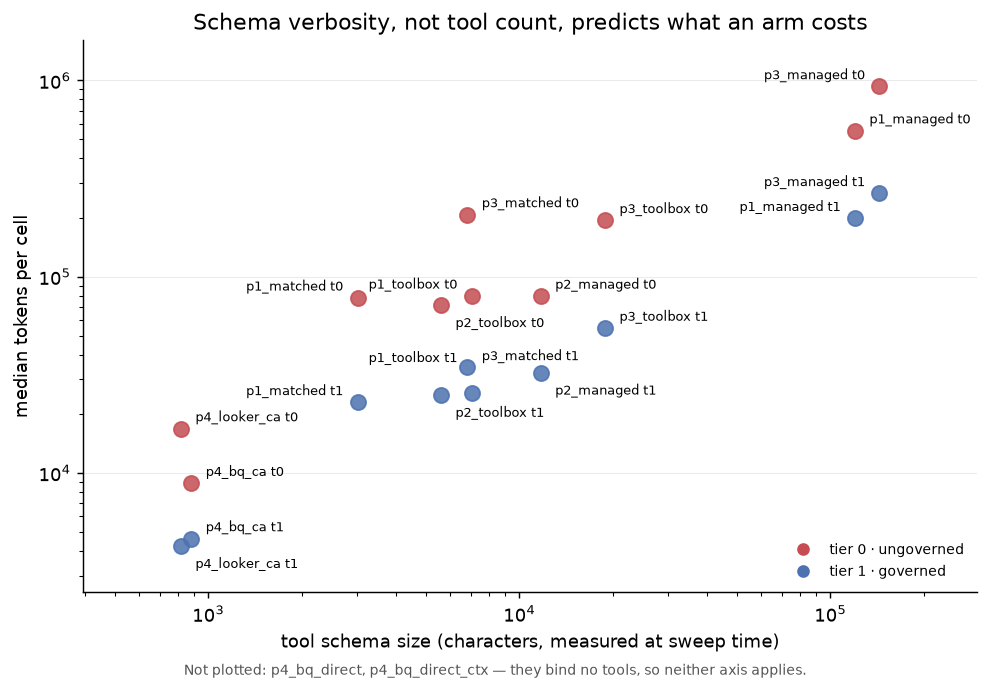

In [8]:
plots.schema_size_vs_cost(scores, meta.get("tool_schemas", {}))

## The two cheapest arms are not measured the same way

Look at the `coverage` column in the headline table. Ten arms say **full**. The
two Conversational Analytics arms say **floor** and the two direct-API arms say
**service only**, and neither is a total. A floor is a lower bound: the API
returns no usage for the Gemini loop CA runs on our behalf, so every token it
spent thinking is missing from the chart above. A service-only arm records a
true zero, because no model runs in this process at all — its whole spend is the
service's, and the columns print `--` rather than 0.

That is easy to read as "CA is cheap." It is not what the number says, and for
one of the two arms it is the opposite of the truth. Cloud Monitoring meters the
same spend from a different interface, and `p4_looker_ca` recorded **18,045**
tokens per cell while actually consuming **392,158** — a 22× understatement that
moves it from the cheapest arm to the third most expensive, behind only the two
managed arms. Its 207 turns ran 1,220 server-side model calls, about six per
turn: the agent loop we thought we had removed, running where the invoice for it
is someone else's.

`p4_bq_ca` reports nothing on that meter, so it stays a floor. Nothing measured
is not the same as nothing spent, and `docs/paths.md` lists the mechanisms that
would explain a genuine zero without picking one.

This is a separate command because the metric is project-wide, time-blocked and
kept for six weeks — none of which is true of the per-cell numbers here:

```bash
uv run python examples/service_tokens.py --baseline 2026-08-25 2026-09-01  # first
make service-tokens                                                        # then
```

Run the baseline first. The metric has no caller label, so attribution is by
time window and only holds if nothing else in the project was using CA. Ours
returns exactly zero, which is what makes the number publishable.

## The tables behind the charts

One to read closely: **Latency**. It is an independent axis, not a proxy for
cost — across the ten arms that spend tokens locally, tokens against wall clock
correlates at about r = 0.1. Every MCP arm spends 4–5s per tool call whatever
its schema size, so its latency is really just turn count. The wrapped CA arms
take 1–3 calls and pay 21–73s for each, because the loop moved server-side. The
two direct-API arms take none: no local agent, no MCP round trips, 10s a cell,
three times faster than anything else here.

The median seconds here are per *cell*. The headline table divides by correct
answers instead, which is what a user actually waits for a usable result, and
that recomputation is unkind to the slow-and-wrong arms.

Cells are excluded from the latency medians when they hit a quota retry, because
one retry carries up to ~300s of backoff sleep and pooling it with clean cells
publishes a fake number. The `excluded` column says how many.

In [9]:
for title, section in (
    ("Capture health", report.capture_health(scores)),
    ("Accuracy", report.accuracy(scores)),
    ("Acquisition vs application", report.acquisition(scores)),
    ("Evidence", report.evidence(scores)),
    ("Latency", report.latency(scores)),
):
    print(f"### {title}\n\n{section}\n")

### Capture health

| config | tier | attempted | scored | failed | quota-retried | CA leak |
|---|---|---|---|---|---|---|
| p1_managed | 0 | 60 | 60 | 0 | 8 | 0% |
| p1_managed | 1 | 60 | 60 | 0 | 1 | 0% |
| p1_toolbox | 0 | 60 | 60 | 0 | 5 | 57% |
| p1_toolbox | 1 | 60 | 60 | 0 | 4 | 32% |
| p2_managed | 0 | 60 | 60 | 0 | 5 | 0% |
| p2_managed | 1 | 60 | 60 | 0 | 4 | 0% |
| p2_toolbox | 0 | 60 | 60 | 0 | 4 | 0% |
| p2_toolbox | 1 | 60 | 60 | 0 | 0 | 0% |
| p3_managed | 0 | 60 | 60 | 0 | 8 | 0% |
| p3_managed | 1 | 60 | 60 | 0 | 2 | 0% |
| p3_toolbox | 0 | 60 | 60 | 0 | 2 | 65% |
| p3_toolbox | 1 | 60 | 60 | 0 | 0 | 30% |
| p1_matched | 0 | 60 | 60 | 0 | 1 | 0% |
| p1_matched | 1 | 60 | 60 | 0 | 1 | 0% |
| p3_matched | 0 | 60 | 60 | 0 | 10 | 0% |
| p3_matched | 1 | 60 | 60 | 0 | 14 | 0% |
| p4_bq_ca | 0 | 60 | 60 | 0 | 7 | 0% |
| p4_bq_ca | 1 | 60 | 60 | 0 | 0 | 0% |
| p4_looker_ca | 0 | 60 | 60 | 0 | 0 | 0% |
| p4_looker_ca | 1 | 60 | 60 | 0 | 0 | 0% |
| p4_bq_direct | 0 | 60 | 60 |

## Argue with the rubric

Every judgement above comes from `src/scoring.py`, which reads the raw capture
and nothing else. Change it, re-run this notebook, and see what moves.

That is not hypothetical. Marking the three anchor-ambiguous questions
unscoreable was exactly this edit, and it republished five captures without
issuing a single query — because scores live beside the capture and never
inside it. Two headline findings shrank as a result. Which ones, and by how
much: [`docs/paths.md`](../docs/paths.md#the-trailing-window-questions-are-anchor-ambiguous).

Three passes are deliberately *not* run here, because each needs a live project:

```bash
make report                                          # + BigQuery cost attribution + LLM judge
uv run python examples/build_results.py --no-judge   # cost attribution only
make service-tokens                                  # CA's server-side model spend
```

What these numbers will and will not reproduce on your own project:
[`docs/reproducing.md`](../docs/reproducing.md).